In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error

import torch.nn as nn
import torch.optim as optim
import math
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset, DataLoader
import datetime

import random
from skopt import BayesSearchCV
from sklearn.metrics import r2_score
from sklearn.model_selection import PredefinedSplit

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
data = pd.read_excel('../Data/New_data11.xlsx')
data_pop = pd.read_excel('../Data/population_2013_2072.xlsx')

In [4]:
for i in range(2013,2025):
    data_pop.loc[data_pop['year']==i,0] = data.loc[data['Year']==i,'Population_0'].iloc[0]
    data_pop.loc[data_pop['year']==i,40] = data.loc[data['Year']==i,'Population_40'].iloc[0]
    data_pop.loc[data_pop['year']==i,60] = data.loc[data['Year']==i,'Population_60'].iloc[0]

In [5]:
Climber = pd.read_excel('../Data/Climber.xlsx')

In [6]:
chuseok_dates = pd.read_excel('../Data/추석날짜.xlsx')

In [7]:
chuseok_week = []
# 각 해의 추석 날짜가 몇 번째 주에 속하는지 계산
for date_str in chuseok_dates['date'].values:
    chuseok_date = date_str.astype('datetime64[s]').astype(datetime.datetime)
    chuseok_week.append(chuseok_date.isocalendar()[1])  # ISO 캘린더에서 주차 계산
print(chuseok_week)

[37, 39, 37, 40, 39, 37, 40, 38, 36, 39, 38, 41, 39, 37, 40, 38, 37, 40, 38, 36, 39, 37, 40, 39, 37, 39, 38, 37, 39, 38, 40, 39, 37, 40, 39, 36, 39, 38, 36, 39, 38, 40, 38, 37, 40, 38, 37, 39, 37, 40, 39, 38, 39, 38, 37, 39, 38]


In [8]:
data['Chuseok'] = 0

In [9]:
for j, i in enumerate(range(2014,2025)):
    data.loc[(data['Year']==i) & (data['Week']>=chuseok_week[j]-2) & (data['Week']<=chuseok_week[j]+2), 'Chuseok']=1

In [10]:
data['Elder_cases'] = data['Cases_60']
data['Elder_incidence'] = 0.0

data['Nonelder_cases'] = data['Cases_0']+data['Cases_40']
data['Nonelder_incidence'] = 0.0

In [11]:
for i in range(2013,2025):
    data.loc[data['Year']==i,'Elder_incidence'] = 1000000*data.loc[data['Year']==i,'Elder_cases']/data_pop.loc[data_pop['year']==i,60].values[0]
    data.loc[data['Year']==i,'Nonelder_incidence'] = 1000000*data.loc[data['Year']==i,'Nonelder_cases']/(data_pop.loc[data_pop['year']==i,40].values[0] + data_pop.loc[data_pop['year']==i,0].values[0])

In [12]:
observed_year_incidence = pd.DataFrame(columns=['year','Total incidence','Elder incidence','Nonelder incidence'])
observed_year_cases = pd.DataFrame(columns=['year','Total cases','Elder cases','Nonelder cases'])
for num, i in enumerate(range(2015,2025)):
    observed_year_incidence.loc[num,'year'] = i
    observed_year_cases.loc[num,'year'] = i
    observed_year_cases.loc[num,'Total cases'] = data.loc[(data['Year']==i),'Cases'].sum()
    observed_year_incidence.loc[num,'Total incidence'] = 1000000*observed_year_cases.loc[num,'Total cases']/data_pop.loc[data_pop['year']==i,[0,40,60]].sum(axis=1).values[0]
    observed_year_incidence.loc[num,'Elder incidence'] = data.loc[(data['Year']==i),'Elder_incidence'].sum()
    observed_year_incidence.loc[num,'Nonelder incidence'] = data.loc[(data['Year']==i),'Nonelder_incidence'].sum()
    observed_year_cases.loc[num,'Elder cases'] = data.loc[(data['Year']==i),'Elder_cases'].sum()
    observed_year_cases.loc[num,'Nonelder cases'] = data.loc[(data['Year']==i),'Nonelder_cases'].sum()

In [13]:
observed_year_incidence['rate']=observed_year_incidence['Elder incidence']/observed_year_incidence['Nonelder incidence']

In [14]:
data['Weekly hiker'] = data['Weekly hiker']*(data['Population_60']/data['Population'])

In [15]:
# hiker = pd.DataFrame(data['Weekly hiker'])
# hiker.to_excel('hiker_1.xlsx',index=None)

In [16]:
start_year = 2015
end_year = 2023

data_train = data[(data['Year']>=start_year) & (data['Year']<end_year)]
data_test = data[data['Year']>=end_year]

In [17]:
features = ['tem','rain', 'hum', 'Chuseok', 'Weekly hiker', 'Tick Density']

In [18]:
target = ['Elder_incidence']

In [19]:
def make_dataset_D(x_data, y_data, window_size):
    x_list = []
    y_list = []
    for i in range(len(x_data) - window_size+1):
        x_list.append(np.array(x_data.iloc[i:i+window_size]))
        y_list.append(np.array(y_data.iloc[i+window_size-1]))
    x_list = np.array(x_list)
    y_list = np.array(y_list).reshape(-1)
    return x_list, y_list

In [20]:
import random
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

In [21]:
seed_value=42

In [22]:
def block_bootstrap_indices(n, block_len, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    idx = []
    while len(idx) < n:
        start = rng.integers(0, n - block_len + 1)
        idx.extend(range(start, start + block_len))
    return np.array(idx[:n])

In [23]:
class DNN(nn.Module):
    def __init__(self, hidden_dim=128, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(len(features)*window_size_DNN, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 4, 1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)

In [24]:
class LSTM(nn.Module):
    def __init__(self, hidden_dim=128, num_layers=2,
                 dropout=0.2):
        super(LSTM, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=len(features),
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc1 = nn.Linear(hidden_dim, hidden_dim//2)
        self.fc2 = nn.Linear(hidden_dim//2, 1)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        h0 = torch.zeros(
            self.num_layers,
            x.shape[0],
            self.hidden_dim,
            device=x.device
        )

        c0 = torch.zeros(
            self.num_layers,
            x.shape[0],
            self.hidden_dim,
            device=x.device
        )

        x, _ = self.lstm(x, (h0, c0))

        x = x[:, -1, :]

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)

        return x

In [25]:
machine_values = ['LR','RF','XGB','DNN','LSTM']
# machine_values = ['LR','RF','XGB']
window_size_num = [6, 7, 8, 8, 8]

In [26]:
for j, i in enumerate(machine_values):
    globals()['window_size_{}'.format(i)] = window_size_num[j]

In [27]:
SSP126_data = pd.read_excel('../Data/SSP126_weekly.xlsx')
SSP245_data = pd.read_excel('../Data/SSP245_weekly.xlsx')
SSP370_data = pd.read_excel('../Data/SSP370_weekly.xlsx')
SSP585_data = pd.read_excel('../Data/SSP585_weekly.xlsx')

In [28]:
SSP_start_year = 2024
SSP_end_year = 2070

In [29]:
best_model = 'LSTM'

In [30]:
test_num = 105
valid_num = 52

seed_value = 42

In [31]:
data_temp = data_train[(data_train['Year']>start_year) | (data_train['Week']>53-globals()['window_size_{}'.format(best_model)]+1)]
data_temp.index = range(len(data_temp))
data_test.index = range(len(data_test))
X = pd.concat([data_temp.loc[:, features],data_test.loc[:, features]])
Y = pd.concat([data_temp[target],data_test[target]])
X.index=range(len(X))
Y.index=range(len(Y))
X_max = X[:-test_num].max()
X_min = X[:-test_num].min()

In [32]:
SSP126_data = SSP126_data[
    ((SSP126_data['year'] > SSP_start_year) |
     ((SSP126_data['year'] == SSP_start_year) & (SSP126_data['week'] > 52-globals()['window_size_{}'.format(best_model)]+1))) &
    (SSP126_data['year'] <= SSP_end_year)
]

SSP245_data = SSP245_data[
    ((SSP245_data['year'] > SSP_start_year) |
     ((SSP245_data['year'] == SSP_start_year) & (SSP245_data['week'] > 52-globals()['window_size_{}'.format(best_model)]+1))) &
    (SSP245_data['year'] <= SSP_end_year)
]

SSP370_data = SSP370_data[
    ((SSP370_data['year'] > SSP_start_year) |
     ((SSP370_data['year'] == SSP_start_year) & (SSP370_data['week'] > 52-globals()['window_size_{}'.format(best_model)]+1))) &
    (SSP370_data['year'] <= SSP_end_year)
]

SSP585_data = SSP585_data[
    ((SSP585_data['year'] > SSP_start_year) |
     ((SSP585_data['year'] == SSP_start_year) & (SSP585_data['week'] > 52-globals()['window_size_{}'.format(best_model)]+1))) &
    (SSP585_data['year'] <= SSP_end_year)
]

# 🔹 인덱스 재설정
SSP126_data.index = range(len(SSP126_data))
SSP245_data.index = range(len(SSP245_data))
SSP370_data.index = range(len(SSP370_data))
SSP585_data.index = range(len(SSP585_data))

In [33]:
SSP126_data.head(15)

,year,week,hum,rain,tem
0,2024,46,75.56,6.97,11.09
1,2024,47,65.39,0.02,7.59
2,2024,48,70.93,0.29,9.39
3,2024,49,67.38,0.83,6.83
4,2024,50,57.39,0.74,0.57
5,2024,51,68.10,1.32,3.55
6,2024,52,64.67,0.27,3.85
7,2025,1,67.78,1.77,5.25
8,2025,2,65.48,1.15,3.80
9,2025,3,51.13,0.09,-0.54


In [34]:
chuseok_dates.rename(columns={'date': 'Chuseok_Date'}, inplace=True)
# 'Chuseok_Date' 열을 datetime 형식으로 변환
chuseok_dates['Chuseok_Date'] = pd.to_datetime(chuseok_dates['Chuseok_Date'], format='%Y-%m-%d')

# 2014년부터 2023년까지의 데이터만 필터링
chuseok_dates = chuseok_dates[chuseok_dates['Chuseok_Date'].dt.year.between(2024, 2070)]

# 결과 확인
print(chuseok_dates[['Chuseok_Date']])

   Chuseok_Date
10   2024-09-17
11   2025-10-06
12   2026-09-25
13   2027-09-15
14   2028-10-03
15   2029-09-22
16   2030-09-12
17   2031-10-01
18   2032-09-19
19   2033-09-08
20   2034-09-27
21   2035-09-16
22   2036-10-04
23   2037-09-24
24   2038-09-13
25   2039-10-02
26   2040-09-21
27   2041-09-10
28   2042-09-28
29   2043-09-17
30   2044-10-05
31   2045-09-25
32   2046-09-15
33   2047-10-04
34   2048-09-22
35   2049-09-11
36   2050-09-30
37   2051-09-19
38   2052-09-07
39   2053-09-26
40   2054-09-16
41   2055-10-05
42   2056-09-24
43   2057-09-13
44   2058-10-02
45   2059-09-21
46   2060-09-09
47   2061-09-28
48   2062-09-17
49   2063-10-06
50   2064-09-25
51   2065-09-15
52   2066-10-03
53   2067-09-23
54   2068-09-11
55   2069-09-29
56   2070-09-19


In [35]:
# 주(week)와 연도를 추가
chuseok_dates['Year'] = chuseok_dates['Chuseok_Date'].dt.year
chuseok_dates['Week'] = chuseok_dates['Chuseok_Date'].dt.isocalendar().week

# 결과 확인
print(chuseok_dates[['Chuseok_Date', 'Year', 'Week']])

   Chuseok_Date  Year  Week
10   2024-09-17  2024    38
11   2025-10-06  2025    41
12   2026-09-25  2026    39
13   2027-09-15  2027    37
14   2028-10-03  2028    40
15   2029-09-22  2029    38
16   2030-09-12  2030    37
17   2031-10-01  2031    40
18   2032-09-19  2032    38
19   2033-09-08  2033    36
20   2034-09-27  2034    39
21   2035-09-16  2035    37
22   2036-10-04  2036    40
23   2037-09-24  2037    39
24   2038-09-13  2038    37
25   2039-10-02  2039    39
26   2040-09-21  2040    38
27   2041-09-10  2041    37
28   2042-09-28  2042    39
29   2043-09-17  2043    38
30   2044-10-05  2044    40
31   2045-09-25  2045    39
32   2046-09-15  2046    37
33   2047-10-04  2047    40
34   2048-09-22  2048    39
35   2049-09-11  2049    36
36   2050-09-30  2050    39
37   2051-09-19  2051    38
38   2052-09-07  2052    36
39   2053-09-26  2053    39
40   2054-09-16  2054    38
41   2055-10-05  2055    40
42   2056-09-24  2056    38
43   2057-09-13  2057    37
44   2058-10-02  205

In [36]:
def add_chuseok_flag_to_weekly_data(weekly_data, chuseok_dates):
    # Chuseok_Flag 열 추가 및 초기화
    weekly_data['Chuseok'] = 0

    # 각 연도의 추석 주를 기준으로 전후 범위 설정 (추석 전 2주, 추석 후 4주)
    for _, row in chuseok_dates.iterrows():
        chuseok_year = row['Year']
        chuseok_week = row['Week']
        
        # 추석 전 2주 및 추석 후 4주 주 번호 계산
        start_week = chuseok_week - 2
        end_week = chuseok_week + 2

        # 플래그 설정 (연도 경계 고려)
        weekly_data.loc[
            ((weekly_data['year'] == chuseok_year) & (weekly_data['week'].between(start_week, end_week))) |
            ((weekly_data['year'] == chuseok_year - 1) & (start_week < 1) & (weekly_data['week'] > 50)) |
            ((weekly_data['year'] == chuseok_year + 1) & (end_week > 52) & (weekly_data['week'] < 7)),
            'Chuseok'
        ] = 1

    return weekly_data

In [37]:
# 추석 플래그 추가
SSP126_data = add_chuseok_flag_to_weekly_data(SSP126_data, chuseok_dates)
SSP245_data = add_chuseok_flag_to_weekly_data(SSP245_data, chuseok_dates)
SSP370_data = add_chuseok_flag_to_weekly_data(SSP370_data, chuseok_dates)
SSP585_data = add_chuseok_flag_to_weekly_data(SSP585_data, chuseok_dates)

In [38]:
SSP126_data

,year,week,hum,rain,tem,Chuseok
0,2024,46,75.56,6.97,11.09,0
1,2024,47,65.39,0.02,7.59,0
2,2024,48,70.93,0.29,9.39,0
3,2024,49,67.38,0.83,6.83,0
4,2024,50,57.39,0.74,0.57,0
...,...,...,...,...,...,...
2394,2070,48,66.91,1.05,2.64,0
2395,2070,49,63.61,2.00,4.76,0
2396,2070,50,60.63,0.91,0.47,0
2397,2070,51,52.45,0.15,-0.17,0


In [39]:
# 주별 등산객 데이터 파일 경로
weekly_hiker_data_path = "../Data/Weekly_hiker_data.xlsx"

# 기존 주별 데이터 불러오기
weekly_data = pd.read_excel(weekly_hiker_data_path)

In [40]:
def add_weekly_hiker_to_existing_data(original_weekly_data, new_weekly_data):
    # 컬럼명을 소문자로統一
    new_weekly_data.rename(columns={"Year": "year", "Week": "week", "Weekly_hiker" : "Weekly hiker"}, inplace=True)
    # 필요한 열만 선택하여 병합 (Year, Week 기준)
    new_weekly_data = new_weekly_data[["year", "week", "Weekly hiker"]]
    
    # 기존 데이터에 새로운 변수 추가 (기존 데이터 유지)
    merged_data = original_weekly_data.merge(new_weekly_data, on=["year", "week"], how="left")

    return merged_data

In [41]:
# 추석 플래그 추가
SSP126_data = add_weekly_hiker_to_existing_data(SSP126_data, weekly_data)
SSP245_data = add_weekly_hiker_to_existing_data(SSP245_data, weekly_data)
SSP370_data = add_weekly_hiker_to_existing_data(SSP370_data, weekly_data)
SSP585_data = add_weekly_hiker_to_existing_data(SSP585_data, weekly_data)

In [42]:
tick_126 = pd.read_excel("../Data/SSP126_weekly_tick_density_ver4.xlsx")
tick_245 = pd.read_excel("../Data/SSP245_weekly_tick_density_ver4.xlsx")
tick_370 = pd.read_excel("../Data/SSP370_weekly_tick_density_ver4.xlsx")
tick_585 = pd.read_excel("../Data/SSP585_weekly_tick_density_ver4.xlsx")

# 🔹 컬럼 이름 변경
tick_126 = tick_126.rename(columns={'Value': "Tick Density"})
tick_126 = tick_126.rename(columns={'Week': 'week'})
tick_126 = tick_126.rename(columns={'Year': 'year'})
tick_245 = tick_245.rename(columns={'Value': "Tick Density"})
tick_245 = tick_245.rename(columns={'Week': 'week'})
tick_245 = tick_245.rename(columns={'Year': 'year'})
tick_370 = tick_370.rename(columns={'Value': "Tick Density"})
tick_370 = tick_370.rename(columns={'Week': 'week'})
tick_370 = tick_370.rename(columns={'Year': 'year'})
tick_585 = tick_585.rename(columns={'Value': "Tick Density"})
tick_585 = tick_585.rename(columns={'Week': 'week'})
tick_585 = tick_585.rename(columns={'Year': 'year'})

In [43]:
# 🔹 진드기 예측값을 기존 데이터에 병합 (Year, Week 기준)
SSP126_data = pd.merge(SSP126_data, tick_126[['year', 'week', 'Tick Density']], on=['year', 'week'], how='left')
SSP245_data = pd.merge(SSP245_data, tick_245[['year', 'week', 'Tick Density']], on=['year', 'week'], how='left')
SSP370_data = pd.merge(SSP370_data, tick_370[['year', 'week', 'Tick Density']], on=['year', 'week'], how='left')
SSP585_data = pd.merge(SSP585_data, tick_585[['year', 'week', 'Tick Density']], on=['year', 'week'], how='left')

In [44]:
SSP126_data

,year,week,hum,rain,tem,Chuseok,Weekly hiker,Tick Density
0,2024,46,75.56,6.97,11.09,0,1102500,1.4
1,2024,47,65.39,0.02,7.59,0,1102500,1.4
2,2024,48,70.93,0.29,9.39,0,1025704,1.4
3,2024,49,67.38,0.83,6.83,0,564928,0.0
4,2024,50,57.39,0.74,0.57,0,564928,0.0
...,...,...,...,...,...,...,...,...
2394,2070,48,66.91,1.05,2.64,0,747950,NaN
2395,2070,49,63.61,2.00,4.76,0,379330,NaN
2396,2070,50,60.63,0.91,0.47,0,379330,NaN
2397,2070,51,52.45,0.15,-0.17,0,379330,NaN


In [45]:
SSP_num = ['SSP126','SSP245','SSP370','SSP585']

In [46]:
file_path = '../Data/전국미래인구 데이터.xlsx'
population_data = pd.ExcelFile(file_path)
population_df = population_data.parse('Sheet1')
print(type(population_df))
population_df

<class 'pandas.core.frame.DataFrame'>


,year,Population,Population_0,Population_40,Population_0_60,Population_60,Population_70,Population_80,Population_60_70,Population_70_80,60~70세 비율(%),70~80세 비율(%),80세 이상 비율(%),고령층 비율(%)
0,2013,50428893,25487419,16475263,41962682,8466211,4108151,1125228,4358060,2982923,0.514759,0.352333,0.132908,0.167884
1,2014,50746659,25119797,16808515,41928312,8818347,4271397,1209247,4546950,3062150,0.515624,0.347248,0.137129,0.173772
2,2015,51014947,24797275,16925673,41722948,9291999,4435537,1305490,4856462,3130047,0.522650,0.336854,0.140496,0.182143
3,2016,51217803,24489367,16977011,41466378,9751425,4547079,1417791,5204346,3129288,0.533701,0.320906,0.145393,0.190391
4,2017,51361911,24150398,16975085,41125483,10236428,4779541,1528426,5456887,3251115,0.533085,0.317602,0.149312,0.199300
5,2018,51585058,23862545,16967360,40829905,10755153,5009497,1634958,5745656,3374539,0.534224,0.313760,0.152016,0.208494
6,2019,51764822,23519115,16928764,40447879,11316943,5240372,1764631,6076571,3475741,0.536945,0.307127,0.155928,0.218622
7,2020,51836239,23036763,16833239,39870002,11966237,5489635,1890824,6476602,3598811,0.541240,0.300747,0.158013,0.230847
8,2021,51769539,22437233,16697692,39134925,12634614,5674954,2016985,6959660,3657969,0.550841,0.289520,0.159640,0.244055
9,2022,51672569,21842803,16700520,38543323,13129246,5917283,2155978,7211963,3761305,0.549305,0.286483,0.164212,0.254085


In [47]:
population_df.columns

Index(['year', 'Population', 'Population_0', 'Population_40',
       'Population_0_60', 'Population_60', 'Population_70', 'Population_80',
       'Population_60_70', 'Population_70_80', '60~70세 비율(%)', '70~80세 비율(%)',
       '80세 이상 비율(%)', '고령층 비율(%)'],
      dtype='object')

In [48]:
for i in SSP_num:
    globals()['{}_data'.format(i)]['Weekly hiker'] = globals()['{}_data'.format(i)]['Weekly hiker'].astype(float)
    for j in range(2024,2071):
        ratio = (
            population_df.loc[population_df['year'] == j, 'Population_60'].item()
            / population_df.loc[population_df['year'] == j, 'Population'].item()
        )
        globals()['{}_data'.format(i)].loc[globals()['{}_data'.format(i)]['year']==j,'Weekly hiker'] = globals()['{}_data'.format(i)].loc[globals()['{}_data'.format(i)]['year']==j,'Weekly hiker'] * ratio

In [49]:
SSP126_data_s = (SSP126_data[features] - X_min) / (X_max - X_min)
SSP245_data_s = (SSP245_data[features] - X_min) / (X_max - X_min)
SSP370_data_s = (SSP370_data[features] - X_min) / (X_max - X_min)
SSP585_data_s = (SSP585_data[features] - X_min) / (X_max - X_min)

In [50]:
def make_dataset_SSP(x_data, window_size):
    x_list = []
    for i in range(len(x_data) - window_size+1):
        x_list.append(np.array(x_data.iloc[i:i+window_size]))
    x_list = np.array(x_list)
    x_list = torch.tensor(x_list, dtype=torch.float32)
    return x_list

In [51]:
n_boot = 1000

In [52]:
for i in SSP_num:
    globals()['{}_tensor'.format(i)] = make_dataset_SSP(globals()['{}_data_s'.format(i)], globals()['window_size_{}'.format(best_model)])
    globals()['pred_{}'.format(i)] = np.zeros((len(globals()['{}_tensor'.format(i)]), n_boot), dtype=float)

In [53]:
forecasting_load = './model_CI_best_final/'
# forecasting_load = './model_CI_forecast_2/'

In [54]:
checkpoint = torch.load(
    './hyperparameter_2/LSTM_model_Regression_8.pth',
    map_location=device,
    weights_only=False
)
best_params = checkpoint["best_params"]
LSTM_model = LSTM(hidden_dim=int(best_params["hidden_dim"]), num_layers=int(best_params["num_layers"]), dropout=float(best_params["dropout"])).to(device)

LSTM_model.load_state_dict(checkpoint['model_state_dict'])
LSTM_model.eval()
df_fitted = pd.DataFrame()
for i in SSP_num:
    globals()[f'fitted_pred_{i}'] = (
            LSTM_model(globals()[f'{i}_tensor'].to(device))
            .detach()
            .cpu()
            .numpy()
            .ravel()
        )

In [55]:
n_week = len(globals()[f'fitted_pred_{SSP_num[0]}'])
years = 2025 + np.arange(n_week) // 52
weeks = np.arange(n_week) % 52 + 1

df_fitted['Year'] = years
df_fitted['Week'] = weeks

for i in SSP_num:

    pred = np.clip(globals()[f'fitted_pred_{i}'], 0, None)

    # 각 주에 대응되는 연도별 인구(백만 명 단위)
    pop = (
        population_df
        .set_index('year')
        .loc[years, 'Population_60']
        .to_numpy()
        / 1_000_000
    )

    # 주별 case 수
    df_fitted[f'{i}'] = pred * pop

# ==========================
# 연도별 총 감염자 수(52주 합)
# ==========================
df_fitted_annual = (
    df_fitted
    .groupby('Year', as_index=False)
    .sum()
)

df_fitted_annual.to_excel(
    'fitted_prediction_annual_case.xlsx',
    index=False
)

In [56]:
df_fitted_annual

,Year,Week,SSP126,SSP245,SSP370,SSP585
0,2025,1378,153.111055,172.696323,153.415881,149.265888
1,2026,1378,161.606264,184.725946,161.020429,183.749514
2,2027,1378,186.087675,164.051568,153.971122,168.007227
3,2028,1378,154.338249,191.890603,178.413336,179.911527
4,2029,1378,167.234973,180.054549,156.149158,176.924131
5,2030,1378,173.604269,203.585566,199.939478,169.125007
6,2031,1378,205.854386,160.268004,179.901375,187.123194
7,2032,1378,173.228329,195.339397,198.152426,195.524877
8,2033,1378,194.775923,219.860665,198.799927,185.758974
9,2034,1378,191.835589,206.449115,208.356148,243.050619


In [57]:
# ssp_cols = [f'SSP{i}' for i in SSP_num]

# peak_list = []

# for col in ssp_cols:
#     temp = (
#         df_fitted
#         .loc[df_fitted.groupby('Year')[col].idxmax(), ['Year', 'Week', col]]
#         .rename(columns={
#             'Week': f'{col}_peak_week',
#             col: f'{col}_peak_case'
#         })
#         .reset_index(drop=True)
#     )

#     peak_list.append(temp)

# df_peak_week = peak_list[0]

# for temp in peak_list[1:]:
#     df_peak_week = df_peak_week.merge(temp, on='Year', how='left')

# # df_peak_week.to_excel(
# #     'fitted_prediction_peak_week_by_year.xlsx',
# #     index=False
# # )

In [58]:
# df_peak_week

In [59]:
df_fitted_annual

,Year,Week,SSP126,SSP245,SSP370,SSP585
0,2025,1378,153.111055,172.696323,153.415881,149.265888
1,2026,1378,161.606264,184.725946,161.020429,183.749514
2,2027,1378,186.087675,164.051568,153.971122,168.007227
3,2028,1378,154.338249,191.890603,178.413336,179.911527
4,2029,1378,167.234973,180.054549,156.149158,176.924131
5,2030,1378,173.604269,203.585566,199.939478,169.125007
6,2031,1378,205.854386,160.268004,179.901375,187.123194
7,2032,1378,173.228329,195.339397,198.152426,195.524877
8,2033,1378,194.775923,219.860665,198.799927,185.758974
9,2034,1378,191.835589,206.449115,208.356148,243.050619


In [60]:
df_fitted.to_excel('fitted_prediction_case.xlsx', index=False)

In [61]:
for i in SSP_num:
    for b_num in range(n_boot):
        if best_model=='LSTM':
            LSTM_model = LSTM(hidden_dim=64, num_layers=3, dropout=0.4).to(device)
            
            state_dict = torch.load(
                forecasting_load + 'LSTM_model_Regression_' + str(b_num) + '.pth',
                map_location=device,
                weights_only=True
            )
            LSTM_model.load_state_dict(state_dict)
            LSTM_model.eval()
            pred_temp = LSTM_model(globals()['{}_tensor'.format(i)].to(device)).detach().cpu().numpy()
            globals()['pred_{}'.format(i)][:, b_num] = pred_temp.ravel()
        
        if b_num%100 == 0:
            print('LSTM, num=',b_num)

LSTM, num= 0
LSTM, num= 100
LSTM, num= 200
LSTM, num= 300
LSTM, num= 400
LSTM, num= 500
LSTM, num= 600
LSTM, num= 700
LSTM, num= 800
LSTM, num= 900
LSTM, num= 0
LSTM, num= 100
LSTM, num= 200
LSTM, num= 300
LSTM, num= 400
LSTM, num= 500
LSTM, num= 600
LSTM, num= 700
LSTM, num= 800
LSTM, num= 900
LSTM, num= 0
LSTM, num= 100
LSTM, num= 200
LSTM, num= 300
LSTM, num= 400
LSTM, num= 500
LSTM, num= 600
LSTM, num= 700
LSTM, num= 800
LSTM, num= 900
LSTM, num= 0
LSTM, num= 100
LSTM, num= 200
LSTM, num= 300
LSTM, num= 400
LSTM, num= 500
LSTM, num= 600
LSTM, num= 700
LSTM, num= 800
LSTM, num= 900


In [63]:
for i in SSP_num:
    train_cols = [f"boot_{i+1:03d}" for i in range(n_boot)]

    globals()['pred_{}'.format(i)] = pd.DataFrame(globals()['pred_{}'.format(i)], columns=train_cols)
    
    globals()['pred_summary_{}'.format(i)] = pd.DataFrame({
        "mean": globals()['pred_{}'.format(i)].mean(axis=1),
        "p025":  globals()['pred_{}'.format(i)].quantile(0.025, axis=1),
        "p05":  globals()['pred_{}'.format(i)].quantile(0.05, axis=1),
        "p25":  globals()['pred_{}'.format(i)].quantile(0.25, axis=1),
        "p50":  globals()['pred_{}'.format(i)].quantile(0.50, axis=1),
        "p75":  globals()['pred_{}'.format(i)].quantile(0.75, axis=1),
        "p05":  globals()['pred_{}'.format(i)].quantile(0.95, axis=1),
        "p975":  globals()['pred_{}'.format(i)].quantile(0.975, axis=1),
    })

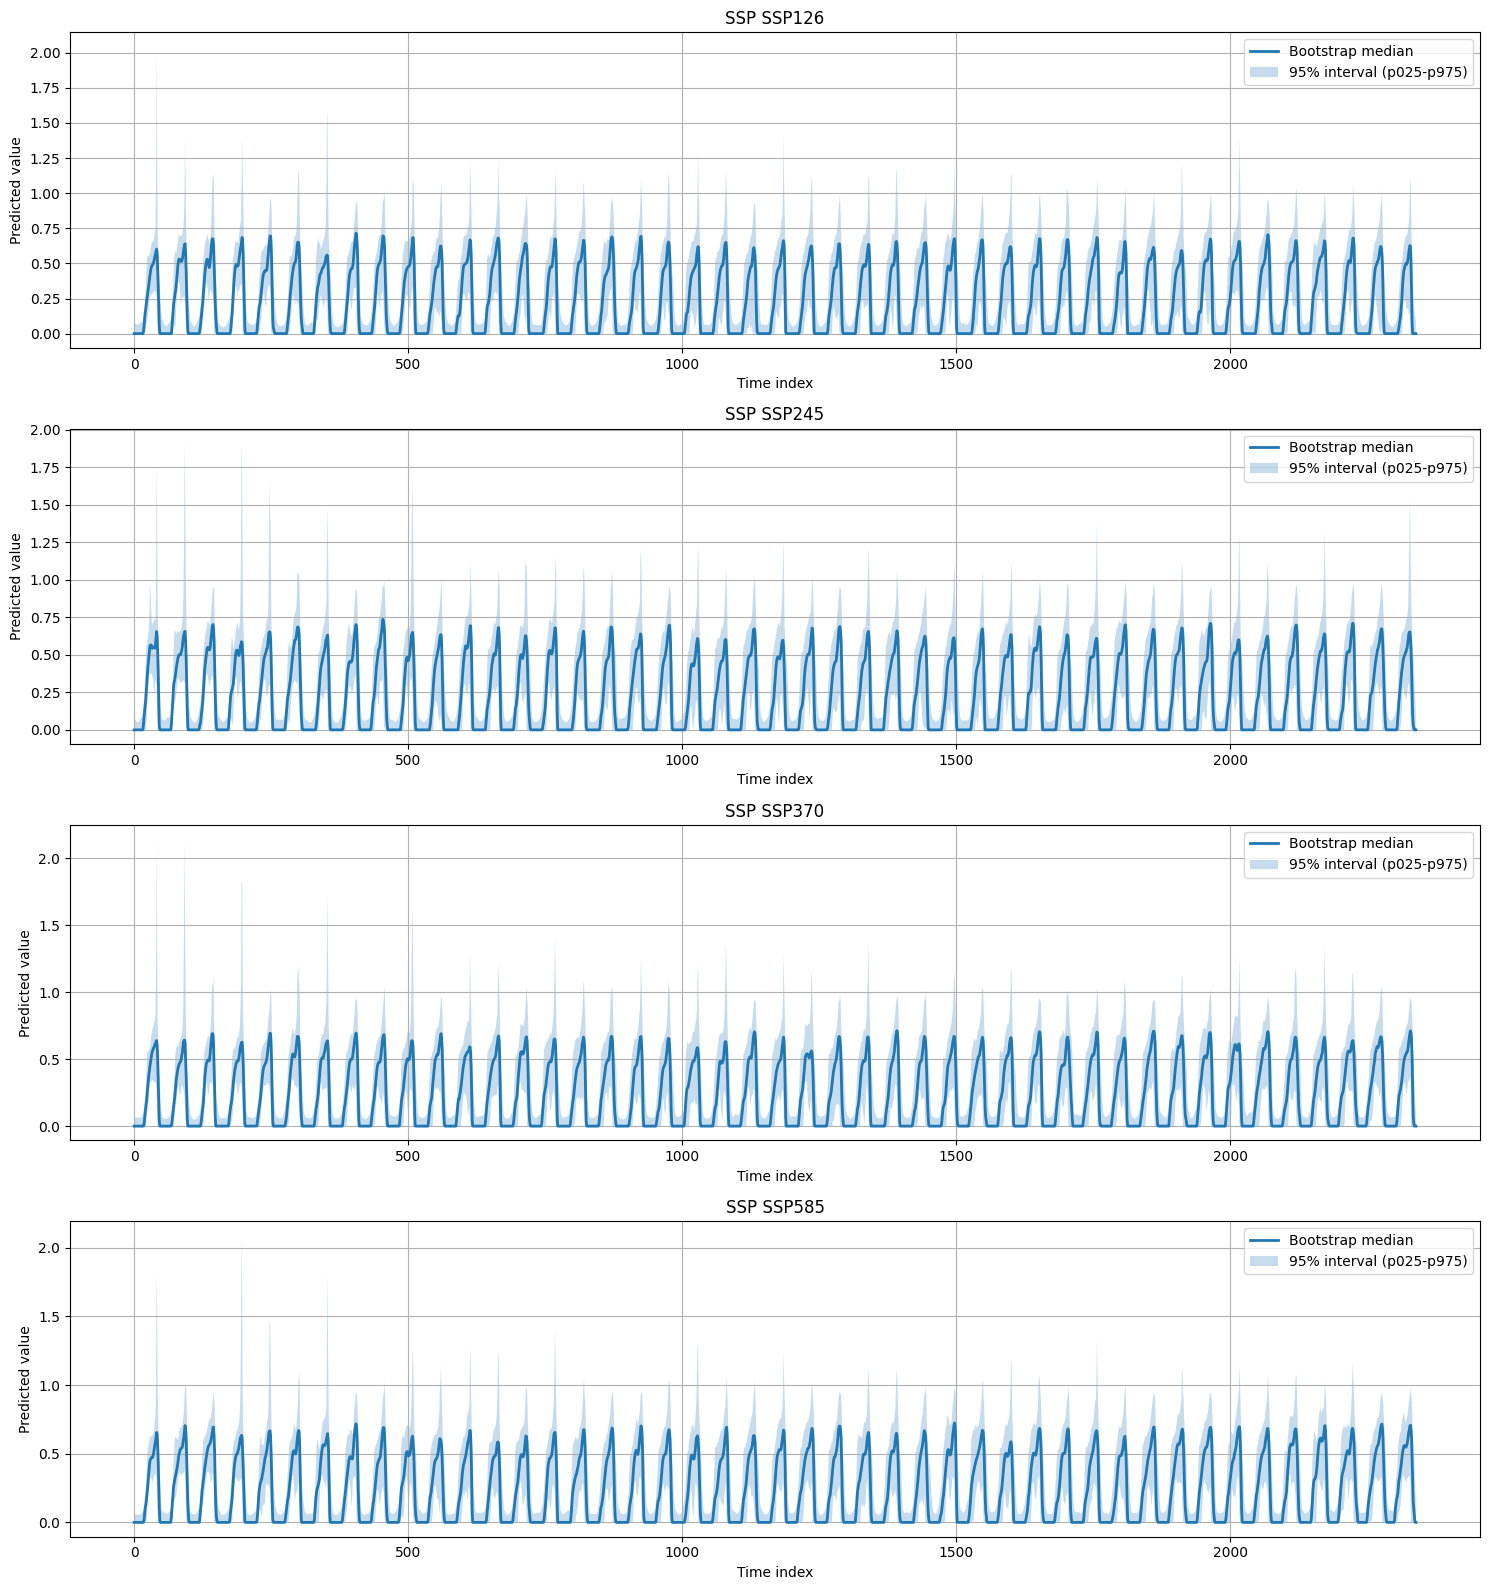

In [64]:
fig, axes = plt.subplots(
    nrows=len(SSP_num),
    ncols=1,
    figsize=(15, 4 * len(SSP_num))
)

if len(SSP_num) == 1:
    axes = [axes]

for row, ssp in enumerate(SSP_num):

    pred_summary = globals()[f'pred_summary_{ssp}']
    ax = axes[row]

    x_pred = np.arange(len(pred_summary))

    ax.plot(
        x_pred,
        pred_summary['p50'],
        linewidth=2,
        label='Bootstrap median'
    )

    ax.fill_between(
        x_pred,
        pred_summary['p025'],
        pred_summary['p975'],
        alpha=0.25,
        label='95% interval (p025-p975)'
    )

    ax.set_title(f'SSP {ssp}')
    ax.set_xlabel('Time index')
    ax.set_ylabel('Predicted value')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [65]:
start_year = 2025

for ssp in SSP_num:

    df_weekly = globals()[f'pred_{ssp}']   # 주별 bootstrap 결과

    # 52주 단위로 자르기 위해 남는 주 제거
    n_years = len(df_weekly) // 52
    df_weekly_cut = df_weekly.iloc[:n_years * 52]

    # 연도 라벨
    years = np.arange(start_year, start_year + n_years)

    # 52주씩 묶어서 연도별 합
    df_annual = (
        df_weekly_cut
        .groupby(np.arange(len(df_weekly_cut)) // 52)
        .sum()
    )

    df_annual.index = years

    globals()[f'pred_annual_{ssp}'] = df_annual

    # 연도별 bootstrap summary
    globals()[f'pred_annual_summary_{ssp}'] = pd.DataFrame({
        "mean": df_annual.mean(axis=1),
        "p025": df_annual.quantile(0.025, axis=1),
        "p05": df_annual.quantile(0.05, axis=1),
        "p25": df_annual.quantile(0.25, axis=1),
        "p50":  df_annual.quantile(0.50, axis=1),
        "p75": df_annual.quantile(0.75, axis=1),
        "p95": df_annual.quantile(0.95, axis=1),
        "p975": df_annual.quantile(0.975, axis=1),
    })

In [80]:
import sys
import sklearn
import xgboost
import torch

print("Python version      :", sys.version)
print("scikit-learn version:", sklearn.__version__)
print("XGBoost version     :", xgboost.__version__)
print("PyTorch version     :", torch.__version__)

Python version      : 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
scikit-learn version: 1.7.2
XGBoost version     : 3.2.0
PyTorch version     : 2.5.1
